# Регуляризация
## Домашнее задание 2


## Структура домашней работы

Домашнее задание состоит из **9 задач**, разделённых на три уровня сложности:

| Уровень | Задачи | Баллы (рекомендуемо) |
|---------|--------|----------------------|
| **Простые** | 1–4 | 3.0 (0.75 за задачу) |
| **Средние** | 5–7 | 4 (1 за задачу) |
| **Сложные** | 8, 9 | 4 (2 за задачу) |

**Итого:** 10 баллов


## Настройка окружения

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# Общие настройки
# ----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# Вспомогательные функции
# ----------------------------
def make_synthetic_linear_regression(
    n: int = 600,
    d: int = 20,
    noise_std: float = 0.5,
    sparsity: float = 0.5,
):
    """Синтетическая линейная регрессия: y = X w_true + noise.
    sparsity: доля нулевых компонент в w_true (примерно).
    """
    X = np.random.randn(n, d).astype(np.float32)
    w_true = np.random.randn(d).astype(np.float32)
    # обнулим часть весов для наглядности (L1 должен это «любить»)
    k0 = int(d * sparsity)
    if k0 > 0:
        zero_idx = np.random.choice(d, size=k0, replace=False)
        w_true[zero_idx] = 0.0
    y = X @ w_true + noise_std * np.random.randn(n).astype(np.float32)
    return X, y, w_true

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    idx = np.random.permutation(n)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])

def mse(pred, target):
    return torch.mean((pred - target) ** 2)

def l2_norm(w: torch.Tensor) -> float:
    return float(torch.norm(w.detach(), p=2).cpu().item())

def sparsity_ratio(w: torch.Tensor, eps: float = 0.01) -> float:
    w_abs = torch.abs(w.detach()).cpu().numpy()
    return float(np.mean(w_abs < eps))

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

# Датасет для задач 2,3,4,5,6,7,9 (один и тот же)
X_np, y_np, w_true_np = make_synthetic_linear_regression(n=800, d=25, noise_std=0.7, sparsity=0.4)
(train_X, train_y), (val_X, val_y), (test_X, test_y) = train_val_test_split(X_np, y_np, 0.6, 0.2)

train_X_t, train_y_t = to_tensor(train_X), to_tensor(train_y).view(-1, 1)
val_X_t, val_y_t     = to_tensor(val_X),   to_tensor(val_y).view(-1, 1)
test_X_t, test_y_t   = to_tensor(test_X),  to_tensor(test_y).view(-1, 1)

w_true_t = to_tensor(w_true_np).view(-1, 1)

print("Shapes:", train_X_t.shape, train_y_t.shape, "| w_true:", w_true_t.shape)

Device: cpu
Shapes: torch.Size([480, 25]) torch.Size([480, 1]) | w_true: torch.Size([25, 1])


---

## Теоретический минимум

### 1) Что такое регуляризация?

**Регуляризация** — набор методов для уменьшения переобучения путём добавления ограничений на параметры.

$$\tilde{E}(\mathbf{w}) = E(\mathbf{w}) + \frac{\lambda}{2} \mathbf{w}^T\mathbf{w}$$

### 2) L2-регуляризация (Weight Decay)

$$\Omega(\mathbf{w}) = \frac{\lambda}{2} ||\mathbf{w}||_2^2 = \frac{\lambda}{2} \sum_j w_j^2$$

Градиент: $\nabla \tilde{E}(\mathbf{w}) = \nabla E(\mathbf{w}) + \lambda \mathbf{w}$

### 3) L1-регуляризация (Lasso)

$$\Omega(\mathbf{w}) = \frac{\lambda}{2} ||\mathbf{w}||_1 = \frac{\lambda}{2} \sum_j |w_j|$$

L1 приводит к **разреженным** решениям.

### 4) Early Stopping

Прекращение обучения когда значение loss на валидации начинает расти. Приблизительно: $\tau \eta \sim 1/\lambda$.

### 5) Dropout

Случайное выключение нейронов с вероятностью $1-\rho$. При инференсе веса эффективно умножаются на $\rho$.

### 6) Residual Connections

$$\mathbf{z}_l = F_l(\mathbf{z}_{l-1}) + \mathbf{z}_{l-1}$$

---

# ПРОСТЫЕ ЗАДАЧИ (Задачи 1-4)

Эти задачи на понимание базовых концепций: L1, L2-регуляризации, dropout, weight decay

## Задача 1: L1 и L2-регуляризация вручную

### Постановка задачи

Реализуйте две функции, которые по вектору весов $w \in \mathbb{R}^d$ и коэффициенту регуляризации $\lambda$ вычисляют скалярные значения регуляризаторов:
- L1 (Lasso): $\Omega_{L1}(w) = \frac{\lambda}{2} \sum_j |w_j|$;
- L2 (Ridge): $\Omega_{L2}(w) = \frac{\lambda}{2} \sum_j w_j^2$.

Протестируйте функции на нескольких векторах весов, сравните с ручным счётом и прокомментируйте, как отличаются численные значения L1 и L2 для одного и того же $w$.

### Теоретический минимум
- Регуляризация добавляет к исходной функции ошибки $E(w)$ штраф: $\tilde{E}(w) = E(w) + \Omega(w)$.
- L2: $\Omega_{L2}(w) = \frac{\lambda}{2}\|w\|_2^2$, градиент по $w$: $\lambda w$.
- L1: $\Omega_{L1}(w) = \frac{\lambda}{2}\|w\|_1$, подградиент по $w_j$: $\lambda\,\text{sign}(w_j)$.
- L1 даёт разреженные решения (многие веса точно 0), L2 — сглаживает веса, но почти не обнуляет.

### Этапы решения
1. Определите функцию `computel1_regularization(weights: torch.Tensor, lambdareg: float)` и реализуйте формулу L1: `lambdareg / 2 * torch.sum(torch.abs(weights))`.
2. Определите функцию `computel2_regularization(weights: torch.Tensor, lambdareg: float)` и реализуйте формулу L2: `lambdareg / 2 * torch.sum(weights ** 2)`.
3. Создайте несколько тестовых векторов `w` и значений `lambdareg`, посчитайте L1 и L2 и сравните с ручным расчётом.
4. Добавьте короткий комментарий: как меняется значение регуляризатора при увеличении $\lambda$ и нормы $w$.


In [ ]:
# Задача 1: L1 и L2-регуляризация вручную

def compute_l1_regularization(w, lam: float):
    """Ω_L1(w) = (λ/2) * sum_j |w_j|"""
    assert "ваш код здесь"

def compute_l2_regularization(w, lam: float):
    """Ω_L2(w) = (λ/2) * sum_j w_j^2"""
    assert "ваш код здесь"

# Тесты
# lam - задайте значение лямбда
# tests = создайте список из трех тензоров (лучше сделать разными)

# for w in tests: - итерируйтесь по списку тензоров, печатайте результаты


# Короткий комментарий:
# - L1 растёт линейно по |w|, L2 — квадратично.
# - Поэтому при наличии «больших» весов L2 штрафует сильнее,
#   а L1 чаще приводит к разреженности (обнулению некоторых весов).

---

## Задача 2: Обучение с L2-регуляризацией

### Постановка задачи

Нужно обучить линейную модель регрессии на синтетическом датасете, добавив к функции потерь L2-регуляризацию. Требуется:
- реализовать обучение модели с различными значениями $\lambda$;
- визуализировать полученные веса (например, столбиковая диаграмма и/или сравнение с истинными весами);
- проанализировать, как величина $\lambda$ влияет на величины весов и качество (MSE на валидации/тесте).

### Теоретический минимум
- Линейная модель: $\hat{y} = Xw$.
- MSE: $E(w) = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$.
- L2-регуляризованный loss: $\tilde{E}(w) = E(w) + \frac{\lambda}{2}\sum_j w_j^2$.
- Градиент: $\nabla_w \tilde{E} = \frac{2}{N} X^T(Xw - y) + \lambda w$.
- Увеличение $\lambda$ уменьшает норму весов, снижая variance и повышая bias.

### Этапы решения
1. Сгенерируйте данные `(X, y)` или воспользуйтесь готовой функцией генерации из ноутбука.
2. Реализуйте функцию обучения линейной модели с L2 (цикл по эпохам, MSE + L2-термин, backward, шаг оптимизатора).
3. Обучите модель для нескольких значений $\lambda$ (например, 0, 0.01, 0.1, 1.0) и сохраните итоговые веса.
4. Постройте графики весов для разных $\lambda` и (при наличии) сравните с истинными весами.
5. Напишите краткий вывод о влиянии $\lambda$ на веса и качество.


In [ ]:
# Задача 2: Обучение с L2-регуляризацией (явно в loss)

class LinearRegressor(nn.Module):
    def __init__(self, d: int):
        assert "ваш код здесь"

    def forward(self, x):
        assert "ваш код здесь"

def train_linear_with_l2(
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    assert "ваш код здесь"

lambdas = [0.0, 0.01, 0.1, 1.0]
results = {}
# for lam in lambdas:


# Визуализируем веса для разных λ и сравним с истинными
plt.figure()
#  ваш код здесь

---

## Задача 3: Weight Decay в оптимизаторе PyTorch

### Постановка задачи

Перепишите обучение из задачи 2, используя встроенный параметр `weight_decay` у оптимизатора PyTorch вместо явного добавления L2 в loss. Сравните результаты (веса и метрики) с задачей 2 и убедитесь, что поведение совпадает при одинаковом $\lambda$.

### Теоретический минимум
- В PyTorch L2-регуляризация обычно задаётся через `weight_decay` в оптимизаторе.
- При `weight_decay = λ` оптимизатор добавляет $\lambda w$ к градиенту параметров, что эквивалентно L2 в функции потерь.
- Нельзя одновременно применять один и тот же L2 и в loss, и в `weight_decay` для тех же параметров (иначе будет двойной штраф).

### Этапы решения
1. Постройте линейную модель, как в задаче 2.
2. Создайте оптимизатор: `optim.SGD(model.parameters(), lr=..., weight_decay=lambda_value)`.
3. Напишите цикл обучения, где loss = MSE без явного L2-термина.
4. Обучите для нескольких `lambda_value` и сохраните веса/метрики.
5. Сравните с результатами задачи 2 и сделайте вывод.


In [ ]:
# Задача 3: Weight Decay в оптимизаторе PyTorch

def train_linear_with_weight_decay(
    weight_decay: float,
    lr: float = 0.05,
    epochs: int = 600,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()

        pred = model(train_X_t)
        loss = mse(pred, train_y_t)  # без явного L2

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model(val_X_t), val_y_t).item()))

    with torch.no_grad():
        test_loss = float(mse(model(test_X_t), test_y_t).item())
        w_hat = model.linear.weight.detach().view(-1, 1).clone()
    return model, w_hat, train_losses, val_losses, test_loss

# Сравнение: явный L2 (из задачи 2) vs weight_decay
compare_lams = [0.0, 0.1, 1.0]
for lam in compare_lams:
    _, w_l2, _, _, test_l2 = train_linear_with_l2(lam, lr=0.05, epochs=400)
    _, w_wd, _, _, test_wd = train_linear_with_weight_decay(lam, lr=0.05, epochs=400)
    diff = float(torch.norm(w_l2 - w_wd).cpu().item())
    print(f"λ={lam:<3} | test_mse L2={test_l2:.4f} | test_mse WD={test_wd:.4f} | ||w_L2 - w_WD||2={diff:.4f}")

---

## Задача 4: Early Stopping

### Постановка задачи

Реализуйте механизм ранней остановки (early stopping), который:
- отслеживает метрику (например, `val_loss`) по эпохам;
- прекращает обучение, если метрика не улучшается более чем на `min_delta` в течение `patience` эпох;
- сохраняет лучшие веса модели (по минимальному `val_loss`).

Интегрируйте этот механизм в цикл обучения одной из моделей из предыдущих задач.

### Теоретический минимум
- Early stopping — форма регуляризации: вместо явного штрафа на веса ограничивается эффективное время обучения.
- Идея: после некоторой эпохи модель начинает переобучаться, и `val_loss` растёт.
- Параметры:
  - `patience` — сколько эпох ждать улучшения;
  - `min_delta` — минимальное изменение loss, считаемое улучшением.

### Этапы решения
1. Реализуйте класс `EarlyStopping` с полями `best_loss`, `patience`, `min_delta`, `counter`, `best_state`.
2. В методе `__call__(val_loss)`:
   - если `val_loss < best_loss - min_delta`: обновить `best_loss`, сохранить `best_state`, сбросить `counter`;
   - иначе: увеличить `counter`.
3. Если `counter >= patience`, вернуть флаг остановки.
4. В цикле обучения после каждой эпохи вызывайте `early_stopping(val_loss)` и прерывайте цикл при срабатывании.
5. После обучения загрузите `best_state` в модель и сравните кривые train/val loss с/без early stopping.


In [ ]:
# Задача 4: Early Stopping

class EarlyStopping:
    def __init__(self, patience: int = 20, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.stopped_epoch = None

    def step(self, val_loss: float, model: nn.Module, epoch: int):
        improved = val_loss < (self.best_loss - self.min_delta)
        if improved:
            self.best_loss = val_loss
            self.counter = 0
            # сохраняем лучшие веса
            self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True
        return False

def train_linear_with_early_stopping(
    lam: float = 0.0,
    lr: float = 0.05,
    max_epochs: int = 2000,
    patience: int = 30,
    min_delta: float = 1e-4,
):
    model = LinearRegressor(train_X_t.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr)

    es = EarlyStopping(patience=patience, min_delta=min_delta)

    train_losses, val_losses = [], []
    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()

        pred = model(train_X_t)
        loss_mse = mse(pred, train_y_t)
        w = model.linear.weight.view(-1)
        loss = loss_mse + 0.5 * lam * torch.sum(w ** 2)

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = float(mse(model(val_X_t), val_y_t).item())
            train_losses.append(float(loss_mse.item()))
            val_losses.append(val_loss)

        if es.step(val_loss, model, epoch):
            break

    # восстановим лучшие веса
    if es.best_state is not None:
        model.load_state_dict(es.best_state)

    with torch.no_grad():
        test_loss = float(mse(model(test_X_t), test_y_t).item())
        w_hat = model.linear.weight.detach().view(-1, 1).clone()

    return model, w_hat, train_losses, val_losses, test_loss, es.stopped_epoch

model_es, w_es, tr_es, va_es, test_es, stopped = train_linear_with_early_stopping(
    lam=0.0, lr=0.05, max_epochs=2000, patience=40, min_delta=1e-4
)
print("Early stopping epoch:", stopped)
print("Test MSE (early stopping):", round(test_es, 4))

Early stopping epoch: 150
Test MSE (early stopping): 0.4578


---

# СРЕДНИЕ ЗАДАЧИ (Задачи 5-7)

Эти задачи требуют комбинирования нескольких концепций и анализа

---

## Задача 5: Сравнение L1 и L2 регуляризации

### Постановка задачи

Обучите две линейные модели на одном и том же датасете:
- одну с L1-регуляризацией (Lasso),
- другую с L2-регуляризацией (Ridge) при одинаковом $\lambda$ (например, 0.1).

Для обеих моделей сравните:
- качество (MSE на валидации/тесте),
- разреженность весов (долю компонент, для которых $|w_j| < 0.01$),
- норму $\|w\|_2$.

### Теоретический минимум
- L1: $\Omega_{L1}(w) = \frac{\lambda}{2}\sum_j |w_j|$ → обычно даёт sparse-веса.
- L2: $\Omega_{L2}(w) = \frac{\lambda}{2}\sum_j w_j^2$ → сжимает веса, но редко делает их строго нулевыми.
- Геометрически: L1-шар — ромб, L2-шар — круг; точка минимума чаще попадает на вершину ромба, «обнуляя» координату.

### Этапы решения
1. Разделите данные на train/val/test (или используйте уже готовые split-функции).
2. Обучите модель с L1-регуляризацией (добавьте L1-термин в loss и реализуйте обновление параметров).
3. Обучите модель с L2-регуляризацией при том же $\lambda$.
4. Для каждой модели вычислите:
   - `test_mse`,
   - `l2_norm = torch.norm(w)`,
   - `sparsity = (torch.abs(w) < 0.01).float().mean()`.
5. Оформите результаты в таблицу/график и сделайте вывод о различиях между L1 и L2.


L1:  val MSE = 0.5117 test MSE = 0.4662 | sparsity = 0.28 | ||w||2 = 3.515
L2:  test MSE = 0.5096 | sparsity = 0.08 | ||w||2 = 3.416


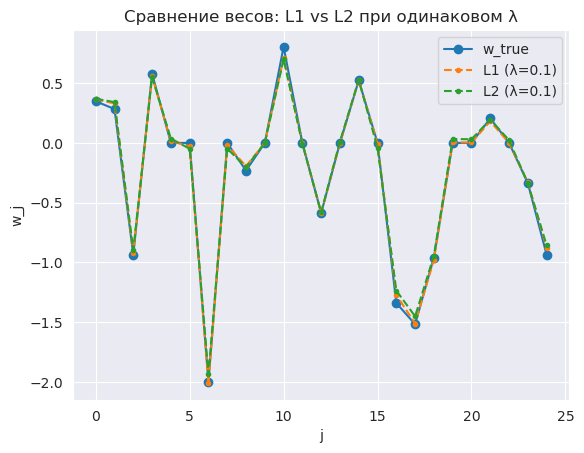

In [ ]:
# Задача 5: Сравнение L1 и L2 регуляризации

def train_linear_with_l1(
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    # model = LinearRegressor(train_X_t.shape[1]).to(device)
    assert "ваш код здесь"


# попробуйте поэкспериментировать с разными параметрами лямбда
lam = 0.1
_, w_l1, val_l1, test_l1 = train_linear_with_l1(lam, lr=0.05, epochs=900)
_, w_l2, _, _, test_l2 = train_linear_with_l2(lam, lr=0.05, epochs=900)

# ваш код вывода L1 и L2 версий здесь

---

## Задача 6: Эксперимент с λ

### Постановка задачи

Исследуйте влияние коэффициента регуляризации $\lambda$ на качество L2-регуляризованной модели и величину весов. Необходимо:
- перебрать набор значений $\lambda$;
- обучить модель для каждого значения;
- собрать и визуализировать зависимости `val_loss` и $\|w\|_2$ от $\lambda$.

### Теоретический минимум
- При маленьком $\lambda$ модель почти без регуляризации → низкий bias, высокий variance (overfitting).
- При большом $\lambda$ веса сильно сжаты → высокий bias, низкий variance (underfitting).
- Оптимальное $\lambda$ обычно выбирают по минимуму val_loss.

### Этапы решения
1. Задайте список `lambdas = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]`.
2. Для каждого `lam` обучите модель с L2-регуляризацией (см. задачу 2) и сохраните `val_loss`, `test_loss`, `l2_norm` весов.
3. Постройте графики: `val_loss` vs `log10(lambda)` и `l2_norm` vs `log10(lambda)`.
4. Найдите значение `lambda`, при котором `val_loss` минимальна.
5. Сформулируйте вывод о наблюдаемом bias-variance tradeoff.


λ=0.0    | val MSE=0.5103 | ||w||2=3.601
λ=0.0001 | val MSE=0.5103 | ||w||2=3.600
λ=0.001  | val MSE=0.5102 | ||w||2=3.599
λ=0.01   | val MSE=0.5102 | ||w||2=3.581
λ=0.1    | val MSE=0.5377 | ||w||2=3.416
λ=1.0    | val MSE=1.9352 | ||w||2=2.349
λ=10.0   | val MSE=8.8202 | ||w||2=0.577


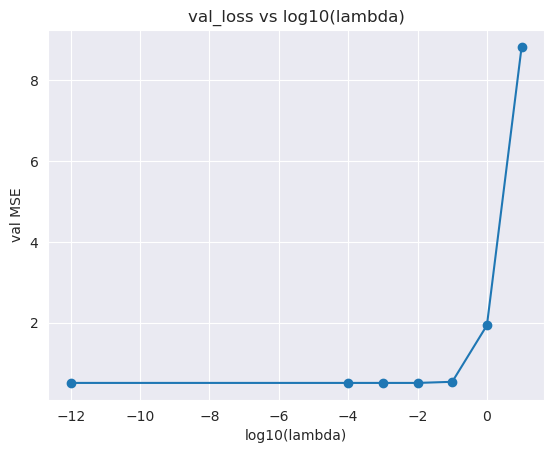

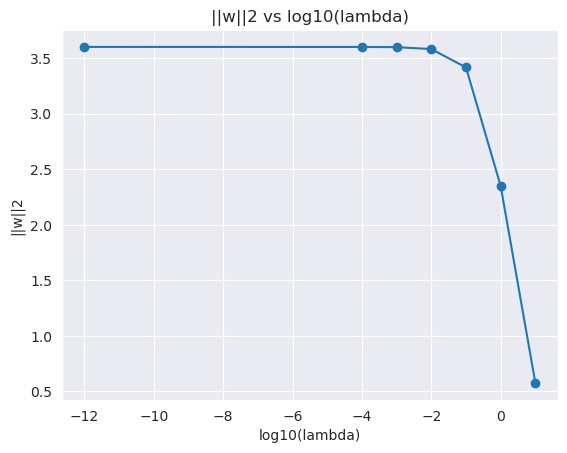

Лучшее λ по val_loss: 0.01 | val_loss: 0.5102


In [ ]:
# Задача 6: Эксперимент с λ (для L2)

lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0] # можно выбрать свои
val_losses = []
test_losses = []
norms = []

# for lam in lambdas:
# ваш код здесь

for lam, v, n in zip(lambdas, val_losses, norms):
    print(f"λ={lam:<6} | val MSE={v:.4f} | ||w||2={n:.3f}")

# Графики зависимостей от log10(lambda)
# ваш код здесь

---

## Задача 7: Визуализация кривых обучения

### Постановка задачи

Необходимо обучить несколько вариантов одной и той же модели (например, без регуляризации, с L2 и с Early Stopping) и визуализировать кривые обучения: train loss и val loss по эпохам. На основе графиков нужно проанализировать, где начинается переобучение и как разные методы регуляризации его сдерживают.

### Теоретический минимум
- Кривая обучения: train/val loss как функция номера эпохи.
- Признак переобучения: train loss продолжает падать, а val loss начинает расти.
- Регуляризация (L2, early stopping) уменьшает разрыв между train и val, сглаживая кривые.

### Этапы решения
1. Реализуйте функцию обучения, которая в каждом запуске возвращает списки `train_losses` и `val_losses`.
2. Обучите минимум три варианта модели: без регуляризации, с L2 и с Early Stopping (используйте реализованный класс).
3. Постройте графики train/val loss по эпохам для каждого варианта (на одном графике или отдельными subplot’ами).
4. Для варианта с Early Stopping отметьте точку остановки.
5. Сформулируйте вывод: у какой модели наименьший разрыв и где видно переобучение.


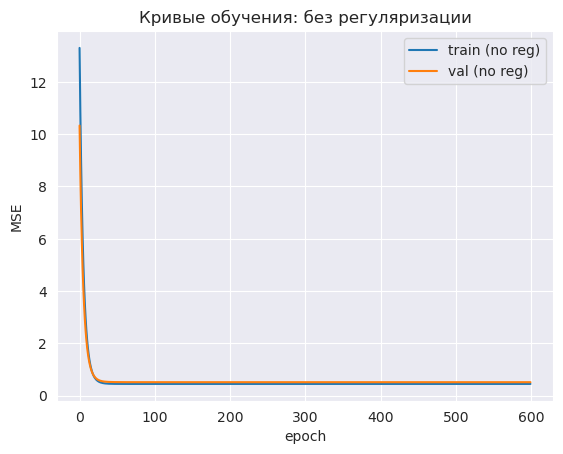

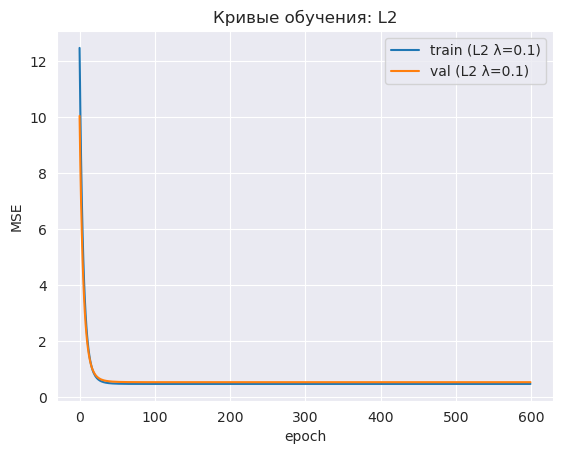

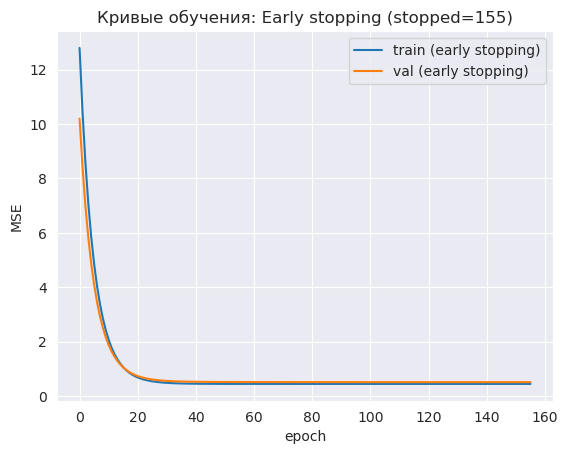

Test MSE:
  no reg      : 0.4577
  L2 (0.1)    : 0.5096
  early stop  : 0.4578


In [ ]:
# Задача 7: Визуализация кривых обучения

# 1) Без регуляризации
# ваш код здесь

# 2) L2-регуляризация
# ваш код здесь

# 3) Early stopping (без явного L2)
# ваш код здесь

# plt.figure()
# выведите три графика сранвнения кривых обучения на валидационной и тестовой выборках

---
# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ

## Общая информация
- **Цель:** Понять когда и почему использовать разные регуляризации

---

## Задача 8: Monte Carlo Dropout

### Постановка задачи

Реализуйте функцию `mc_dropout_predict(model, X, n_samples)`, которая оценивает предсказания и неопределённость регрессионной нейросети с Dropout. Для этого нужно:
- выполнить `n_samples` прямых проходов модели в режиме `train()` (чтобы Dropout был активен);
- накапливать предсказания на одной и той же выборке `X`;
- вернуть среднее и стандартное отклонение предсказаний.

Примените метод к тестовым данным и визуализируйте средние предсказания и доверительный интервал.

### Теоретический минимум
- Dropout: при обучении случайно обнуляются выходы нейронов с вероятностью $p$, при инференсе используется масштабирование.
- Monte Carlo Dropout (Галь, Гхахрамани): оставляем Dropout включённым на инференсе и делаем многократные прогоны; дисперсия по сэмплам ≈ неопределённость модели.
- Для регрессии удобно визуализировать mean ± 2·std как приближённый доверительный интервал.

### Этапы решения
1. Определите MLP-модель с `nn.Dropout(p=...)` между слоями.
2. Реализуйте функцию `mc_dropout_predict(model, X, n_samples=100)`:
   - переведите модель в режим `train()`,
   - в цикле `for _ in range(n_samples)` собирайте предсказания `preds.append(model(X))` без backprop,
   - верните `mean = torch.mean(preds, dim=0)`, `std = torch.std(preds, dim=0)`.
3. Примените к test-данным, постройте график mean и интервала неопределённости.
4. Прокомментируйте, где модель наиболее/наименее уверена.


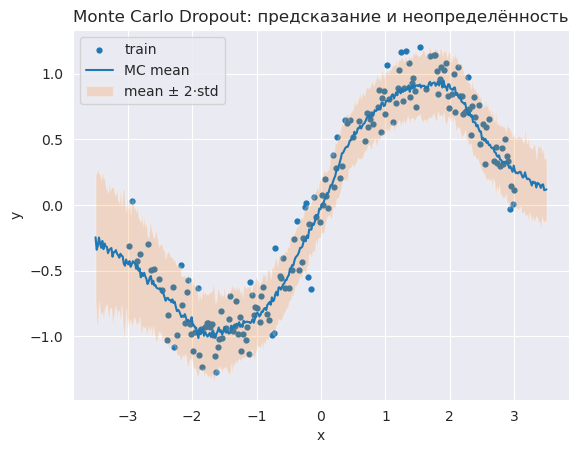

In [ ]:
# Задача 8: Monte Carlo Dropout

# Для наглядной визуализации сделаем 1D-регрессию (синус + шум)
def make_1d_regression(n=250, noise=0.15):
    assert "ваш код здесь"

X1, y1 = make_1d_regression()
# ваш код здесь (сплит, преобразование в тензоры нужного формата)

class MLPDropout(nn.Module):
    def __init__(self, p=0.2):
        assert "ваш код здесь"

    def forward(self, x):
        assert "ваш код здесь"

def train_mlp(model, lr=1e-3, epochs=1500):
        assert "ваш код здесь"

def mc_dropout_predict(model: nn.Module, X: torch.Tensor, n_samples: int = 50):
    """Возвращает mean и std предсказаний при включенном Dropout."""
    assert "ваш код здесь"

# mlp = MLPDropout(p=0.25).to(device)
# mlp = train_mlp...

# Предсказания и неопределённость на плотной сетке
# ваш код здесь

# mean_pred, std_pred =

plt.figure()
# постройте красивый график

---

## Задача 9: Комплексное сравнение

### Постановка задачи

Сравните на одном и том же датасете несколько методов регуляризации:
1. Без регуляризации,
2. L2 (λ = 0.1),
3. L1 (λ = 0.1),
4. Elastic Net (смешение L1 и L2),
5. Early Stopping.

Для каждой модели вычислите:
- Test MSE,
- норму весов $\|w\|_2$,
- разреженность (долю весов, по модулю меньше 0.01).

Соберите результаты в таблицу и проанализируйте, какой метод даёт лучший компромисс между качеством и сложностью модели.

### Теоретический минимум
- Elastic Net: $L = E(w) + \alpha \lambda \|w\|_1 + (1-\alpha) \lambda \|w\|_2^2/2$.
- Разные методы по-разному влияют на bias/variance и структуру весов (сильная L1 → сильно разреженные модели, L2/ES → более гладкие веса, Dropout → «шумная», но устойчиво обобщающая модель).
- Комплексное сравнение по нескольким метрикам позволяет понять, что важнее: точность, интерпретируемость или устойчивость.

### Этапы решения
1. Зафиксируйте один и тот же датасет и разбиение train/val/test.
2. Реализуйте обучение моделей для: NoReg, L2, L1, ElasticNet, EarlyStopping (переиспользуя код предыдущих задач).
3. Для каждой модели посчитайте:
   - `test_mse`,
   - `l2_norm = torch.norm(w)`,
   - `sparsity = (torch.abs(w) < 0.01).float().mean()`.
4. Оформите результаты в Markdown-таблицу или DataFrame.
5. В выводе прокомментируйте, какой метод выглядит наиболее предпочтительным и почему (с точки зрения задачи и требований к модели).


In [ ]:
# Задача 9: Комплексное сравнение

def train_linear_elastic_net(
    lam: float,
    alpha: float = 0.5,   # доля L1
    lr: float = 0.05,
    epochs: int = 900,
):
    assert "ваш код здесь"

# 1) Без регуляризации
# ваш код здесь

# 2) L2 (λ=0.1)
# ваш код здесь

# 3) L1 (λ=0.1)
# ваш код здесь

# 4) Elastic Net (λ=0.1, alpha=0.5)
# ваш код здесь

# 5) Early Stopping (без явного L2)
# ваш код здесь

def summarize(name, w, test_mse_value):
    assert "ваш код здесь"

---